<a href="https://colab.research.google.com/github/ajimotirofiat2-lgtm/AVCAD-ASSIGNMENT/blob/main/Excercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Load the dataset with semicolon as delimiter
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


Now that the data is loaded, let's check the column names and data types to understand the dataset better. This will help us identify the relevant columns for the tasks.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [4]:
# Check data types and unique values for relevant columns
display(df[['temp_ann', 'Salmo trutta fario']].info())
display(df['Salmo trutta fario'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp_ann            4841 non-null   float64
 1   Salmo trutta fario  5011 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 78.4 KB


None

,count
Salmo trutta fario,
1,3035
0,1976


Now that we've confirmed the data types, let's create a box plot to visualize the distribution of `temp_ann` based on the presence or absence of `Salmo trutta fario`.

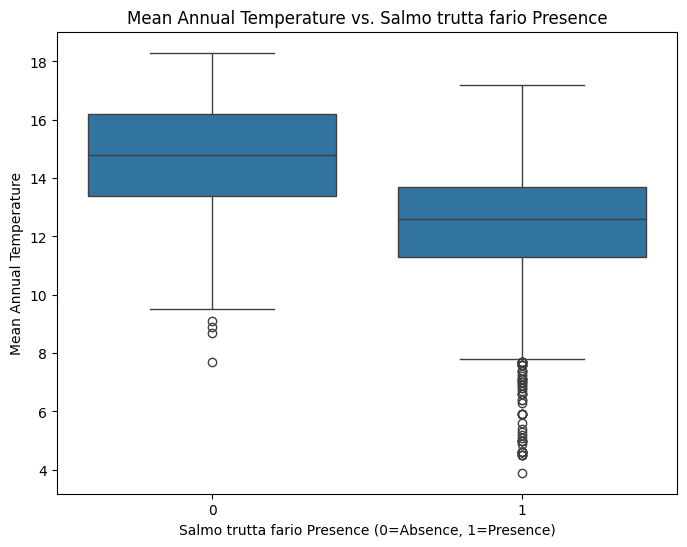

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Salmo trutta fario', y='temp_ann', data=df)
plt.title('Mean Annual Temperature vs. Salmo trutta fario Presence')
plt.xlabel('Salmo trutta fario Presence (0=Absence, 1=Presence)')
plt.ylabel('Mean Annual Temperature')
plt.show()

In [6]:
# Check unique catchment names to ensure correct filtering
display(df['Catchment_name'].unique())

array(['Guadalquivir', 'Tejo', 'Douro', 'Segura', 'Jucar', 'Ebro',
       'Cantabrica', 'Guadia', 'Jucar-Ebro', 'Sur', 'Galiza-Norte',
       'Minho', 'Galiza-Sul', 'Catala', 'Segura-Jucar', 'Garonne',
       'Rhone', 'South_France_E', 'South_France_W', 'Corse',
       'Ombrone-Tevere', 'Campania-South', 'Tevere', 'Arno-Ombrone',
       'Italia-Veneto', 'Sardinia', 'Ombrone', 'Saline-Pescara-Sangro',
       'Oeste', 'Mira', 'Mondego', 'Odelouca', 'Algarve-Sotavento',
       'Algarve-barlavento', 'Sado', 'Tejo-Sado', 'Vouga',
       'EntreDouroeVouga', 'Vouga-Mondego'], dtype=object)

Now that we have confirmed the catchment names, let's filter the DataFrame for 'Minho' and 'Tejo' (Tagus) catchments. Then, we will create separate box plots for each catchment to visualize the relationship between `temp_ann` and `Salmo trutta fario` presence, similar to the overall analysis.

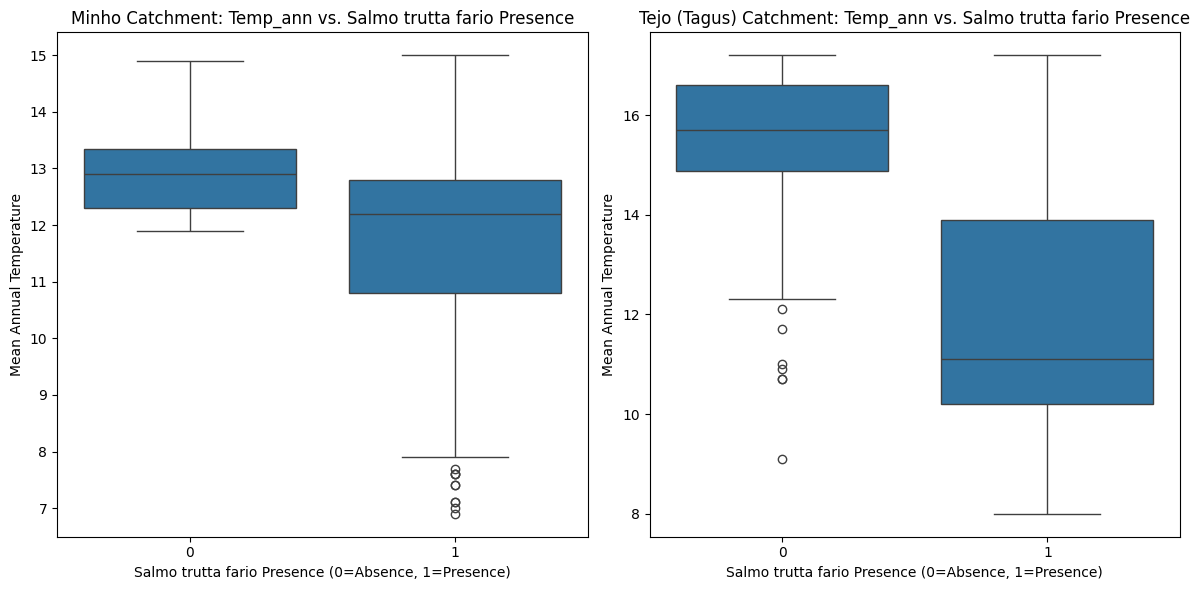

In [7]:
# Filter data for Minho and Tejo (Tagus) catchments
df_minho = df[df['Catchment_name'] == 'Minho']
df_tejo = df[df['Catchment_name'] == 'Tejo']

# Create box plot for Minho catchment
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(x='Salmo trutta fario', y='temp_ann', data=df_minho)
plt.title('Minho Catchment: Temp_ann vs. Salmo trutta fario Presence')
plt.xlabel('Salmo trutta fario Presence (0=Absence, 1=Presence)')
plt.ylabel('Mean Annual Temperature')

# Create box plot for Tejo (Tagus) catchment
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(x='Salmo trutta fario', y='temp_ann', data=df_tejo)
plt.title('Tejo (Tagus) Catchment: Temp_ann vs. Salmo trutta fario Presence')
plt.xlabel('Salmo trutta fario Presence (0=Absence, 1=Presence)')
plt.ylabel('Mean Annual Temperature')

plt.tight_layout()
plt.show()

To formally compare the 'effect sizes' between these catchments, we can perform independent t-tests for each catchment to see if there's a significant difference in `temp_ann` between sites with and without `Salmo trutta fario`. Then, we can compare the differences in means and the p-values from these tests.

In [8]:
from scipy import stats

# Function to perform t-test and print results
def perform_ttest(dataframe, catchment_name):
    # Separate temp_ann for presence (1) and absence (0) of Salmo trutta fario
    temp_ann_presence = dataframe[dataframe['Salmo trutta fario'] == 1]['temp_ann'].dropna()
    temp_ann_absence = dataframe[dataframe['Salmo trutta fario'] == 0]['temp_ann'].dropna()

    if len(temp_ann_presence) > 1 and len(temp_ann_absence) > 1:
        # Perform independent t-test
        t_stat, p_value = stats.ttest_ind(temp_ann_presence, temp_ann_absence, equal_var=False) # Welch's t-test
        mean_diff = temp_ann_presence.mean() - temp_ann_absence.mean()

        print(f"\n--- {catchment_name} Catchment ---")
        print(f"Mean temp_ann for Salmo trutta fario presence: {temp_ann_presence.mean():.2f}")
        print(f"Mean temp_ann for Salmo trutta fario absence: {temp_ann_absence.mean():.2f}")
        print(f"Difference in means (Presence - Absence): {mean_diff:.2f}")
        print(f"T-statistic: {t_stat:.2f}")
        print(f"P-value: {p_value:.3f}")
        if p_value < 0.05:
            print("The difference in mean annual temperature between presence and absence is statistically significant.")
        else:
            print("The difference in mean annual temperature between presence and absence is not statistically significant.")
    else:
        print(f"\n--- {catchment_name} Catchment ---")
        print("Not enough data to perform t-test for both presence and absence groups.")

# Perform t-test for Minho catchment
perform_ttest(df_minho, 'Minho')

# Perform t-test for Tejo (Tagus) catchment
perform_ttest(df_tejo, 'Tejo (Tagus)')


--- Minho Catchment ---
Mean temp_ann for Salmo trutta fario presence: 11.84
Mean temp_ann for Salmo trutta fario absence: 12.96
Difference in means (Presence - Absence): -1.12
T-statistic: -4.30
P-value: 0.001
The difference in mean annual temperature between presence and absence is statistically significant.

--- Tejo (Tagus) Catchment ---
Mean temp_ann for Salmo trutta fario presence: 11.81
Mean temp_ann for Salmo trutta fario absence: 15.51
Difference in means (Presence - Absence): -3.70
T-statistic: -20.18
P-value: 0.000
The difference in mean annual temperature between presence and absence is statistically significant.


For the third task, let's first inspect the `actual_river_slope` column's data type and descriptive statistics to understand its basic distribution. Then, we will use a histogram and a Q-Q plot for visual assessment of normality.

In [9]:
# Check data type and descriptive statistics for 'actual_river_slope'
display(df['Actual_river_slope'].info())
display(df['Actual_river_slope'].describe())

# Drop rows where 'Actual_river_slope' is NaN for analysis
river_slope_data = df['Actual_river_slope'].dropna()

<class 'pandas.core.series.Series'>
RangeIndex: 5011 entries, 0 to 5010
Series name: Actual_river_slope
Non-Null Count  Dtype  
--------------  -----  
4975 non-null   float64
dtypes: float64(1)
memory usage: 39.3 KB


None

,Actual_river_slope
count,4975.000000
mean,14.582432
std,22.596125
min,0.000000
25%,3.509500
50%,8.000000
75%,17.170000
max,774.000000


Now, let's visualize the distribution of `actual_river_slope` using a histogram and a Q-Q plot to visually assess its normality.

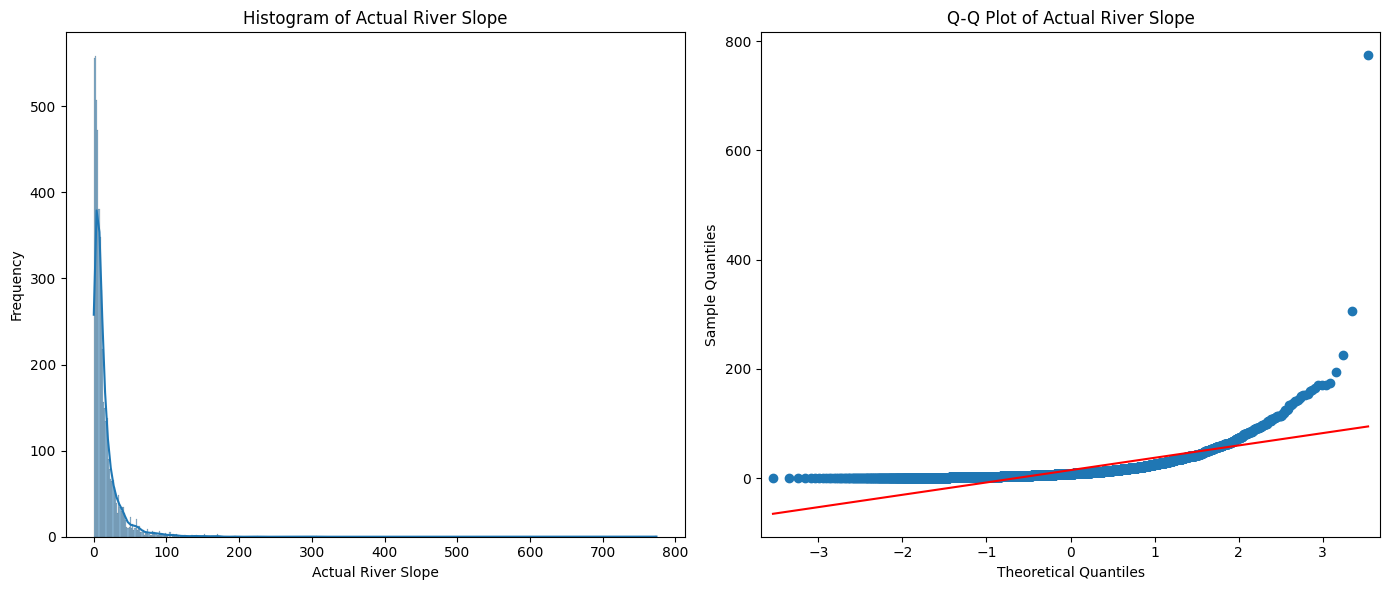

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(river_slope_data, kde=True)
plt.title('Histogram of Actual River Slope')
plt.xlabel('Actual River Slope')
plt.ylabel('Frequency')

# Q-Q plot
plt.subplot(1, 2, 2)
sm.qqplot(river_slope_data, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Actual River Slope')

plt.tight_layout()
plt.show()

For a more formal test of normality, we'll use the Shapiro-Wilk test. This test checks the null hypothesis that the data was drawn from a normal distribution.

In [11]:
from scipy.stats import shapiro

# Perform Shapiro-Wilk test for normality
# Shapiro-Wilk test is sensitive to sample size, especially large ones.
# For very large samples, even small deviations from normality can lead to rejection of the null hypothesis.
# However, it's a direct test for normality, so we'll use it.

stat, p_shapiro = shapiro(river_slope_data)

print(f"Shapiro-Wilk Test Statistic: {stat:.3f}")
print(f"Shapiro-Wilk P-value: {p_shapiro:.3e}")

if p_shapiro > 0.05:
    print("The actual_river_slope appears to be normally distributed (fail to reject H0).")
else:
    print("The actual_river_slope does not appear to be normally distributed (reject H0).")

Shapiro-Wilk Test Statistic: 0.516
Shapiro-Wilk P-value: 2.591e-79
The actual_river_slope does not appear to be normally distributed (reject H0).


For the fourth and final task, we will demonstrate the Central Limit Theorem. We will take 100 samples of 2000 observations of `actual_river_slope` with replacement, compute the mean for each sample, and then plot a histogram of these sample means. Finally, we will test if these 100 mean values are drawn from a normal distribution.

In [12]:
import numpy as np

# Ensure river_slope_data is clean (already done in previous step by dropping NaNs)
# river_slope_data = df['Actual_river_slope'].dropna()

# Parameters for sampling
num_samples = 100
sample_size = 2000

# Create a list to store sample means
sample_means = []

# Take 100 samples of 2000 observations with replacement and compute their means
for _ in range(num_samples):
    sample = np.random.choice(river_slope_data, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Convert the list of sample means to a pandas Series for easier handling
sample_means_series = pd.Series(sample_means)

display(sample_means_series.describe())

,0
count,100.000000
mean,14.568663
std,0.463804
min,13.542124
25%,14.275592
50%,14.552284
75%,14.888682
max,15.804438


Now, let's visualize the distribution of these 100 sample means using a histogram and a Q-Q plot to visually assess their normality, and then perform a Shapiro-Wilk test for a formal assessment.

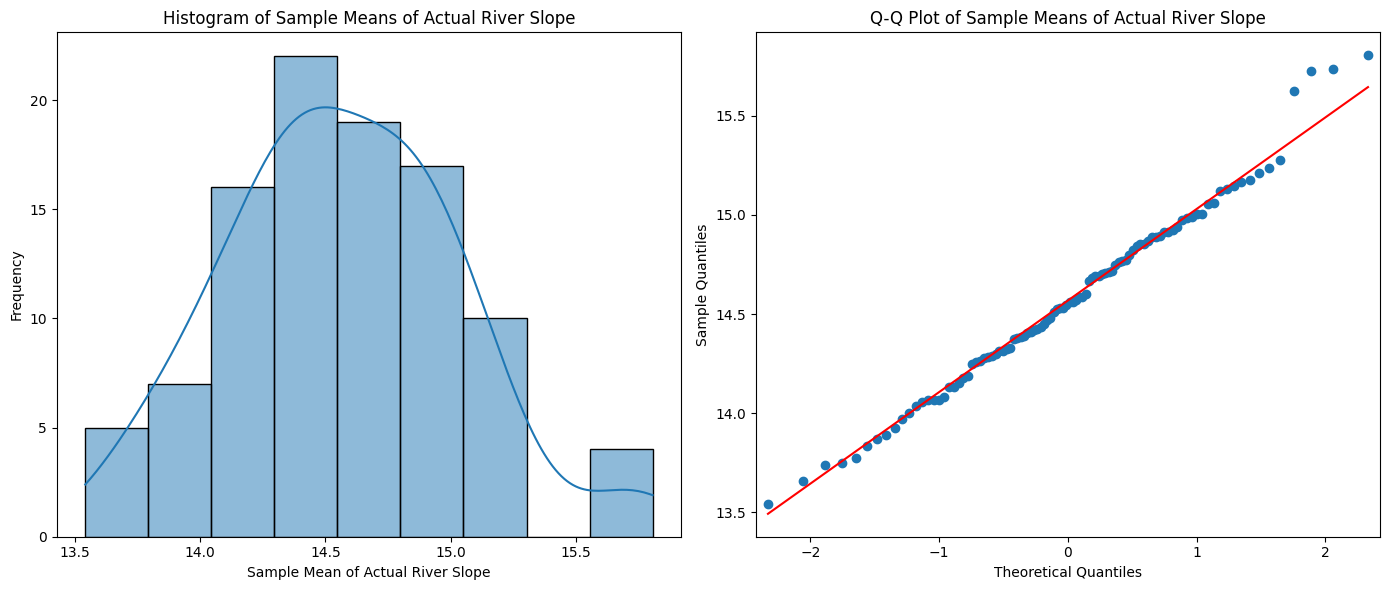


Shapiro-Wilk Test Statistic for Sample Means: 0.988
Shapiro-Wilk P-value for Sample Means: 0.484
The 100 sample means appear to be normally distributed (fail to reject H0).


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro

plt.figure(figsize=(14, 6))

# Histogram of sample means
plt.subplot(1, 2, 1)
sns.histplot(sample_means_series, kde=True)
plt.title('Histogram of Sample Means of Actual River Slope')
plt.xlabel('Sample Mean of Actual River Slope')
plt.ylabel('Frequency')

# Q-Q plot of sample means
plt.subplot(1, 2, 2)
sm.qqplot(sample_means_series, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Sample Means of Actual River Slope')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on sample means
stat_means, p_shapiro_means = shapiro(sample_means_series)

print(f"\nShapiro-Wilk Test Statistic for Sample Means: {stat_means:.3f}")
print(f"Shapiro-Wilk P-value for Sample Means: {p_shapiro_means:.3f}")

if p_shapiro_means > 0.05:
    print("The 100 sample means appear to be normally distributed (fail to reject H0).")
else:
    print("The 100 sample means do not appear to be normally distributed (reject H0).")